# QC: Full-Resolution Inference (3-Class LITHO_FLUMY_AV)

This notebook evaluates full-resolution inference using the 3-class lithology scheme:
- 0 Shale
- 1 Sand
- 2 Silt

Model run used in this notebook:
`/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional/20260811_153252`

Matching training results:
`/mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional/20260811_153252`

In [1]:
import json
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
import torch
from tqdm import tqdm

repo_root = Path.cwd().resolve()
if not (repo_root / 'diffsim').exists():
    candidate = repo_root.parent
    if (candidate / 'diffsim').exists():
        os.chdir(candidate)
        repo_root = candidate

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from diffsim.core.network import Network
from diffsim.core.inference import inference_full_resolution

print('repo_root =', repo_root)

/mnt/sda_data/tharitt/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repo_root = /home/tharitt/working/DiffSim


In [ ]:
# Paths and settings
#RUN_TIMESTAMP = '20260811_153252'
RUN_TIMESTAMP = '20260814_135226'
MODEL_DIR = Path('/mnt/sda_data/tharitt/diffsim/model/case1_flumy_conditional') / RUN_TIMESTAMP
RESULTS_DIR = Path('/mnt/sda_data/tharitt/diffsim/results/case1_flumy_conditional') / RUN_TIMESTAMP
CONFIG_PATH = MODEL_DIR / 'config.json'
RMS_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/rms')

# Optional GT facies directory for quantitative QC (matching file names)
GT_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy_dataset/test/facies')

if not MODEL_DIR.is_dir():
    raise FileNotFoundError(f'Model run directory not found: {MODEL_DIR}')
if not RESULTS_DIR.is_dir():
    raise FileNotFoundError(f'Results run directory not found: {RESULTS_DIR}')
if not CONFIG_PATH.is_file():
    raise FileNotFoundError(f'Model config not found: {CONFIG_PATH}')

CHECKPOINT_PATH = MODEL_DIR / 'best_model.pth'
if not CHECKPOINT_PATH.exists():
    candidates = sorted(MODEL_DIR.glob('checkpoint_epoch_*.pth'))
    if not candidates:
        raise FileNotFoundError(f'No checkpoint found in {MODEL_DIR}')
    CHECKPOINT_PATH = candidates[-1]

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
N_SAMPLES = 16
DDIM_STEPS = 60
ETA = 0.3
MAX_FILES = 12
N_CLASSES = 3

FACIES_NAMES = {
    0: 'Shale',
    1: 'Sand',
    2: 'Silt',
}
FACIES_COLORS = {
    0: '#3E3E3E',
    1: '#E6B422',
    2: '#8FBBD9',
}

cmap6 = mcolors.ListedColormap([FACIES_COLORS[i] for i in range(N_CLASSES)])
norm6 = mcolors.BoundaryNorm(np.arange(-0.5, N_CLASSES + 0.5, 1), cmap6.N)

print('RUN_TIMESTAMP  :', RUN_TIMESTAMP)
print('CONFIG_PATH    :', CONFIG_PATH)
print('CHECKPOINT_PATH:', CHECKPOINT_PATH)
print('RESULTS_DIR    :', RESULTS_DIR)
print('RMS_DIR        :', RMS_DIR)
print('DEVICE         :', DEVICE)

NameError: name 'RUN_TIMESTAMP' is not defined

In [17]:
def load_model(config_path: Path, checkpoint_path: Path, device: str):
    with open(config_path) as f:
        config = json.load(f)

    cond = config['conditional']
    unet_config = {
        'image_size': config['image_size'],
        'in_channel': cond['in_channel'],
        'out_channel': cond['out_channel'],
        'inner_channel': cond['inner_channel'],
        'channel_mults': cond['channel_mults'],
        'attn_res': cond['attn_res'],
        'res_blocks': cond['res_blocks'],
        'dropout': 0.0,
    }

    network = Network(
        unet=unet_config,
        beta_schedule=cond['beta_schedule'],
        module_name=cond.get('module_name', 'guided_diffusion'),
        predict_type=cond.get('predict_type', 'epsilon'),
    )

    ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
    state = ckpt['model_state'] if isinstance(ckpt, dict) and 'model_state' in ckpt else ckpt

    # Checkpoints may contain precomputed schedule buffers not present until set_new_noise_schedule is called.
    incompatible = network.load_state_dict(state, strict=False)
    if incompatible.missing_keys:
        print('Missing keys:', incompatible.missing_keys)
    if incompatible.unexpected_keys:
        print('Unexpected keys (ignored):', incompatible.unexpected_keys)

    network.to(device)
    network.eval()
    return network

network = load_model(CONFIG_PATH, CHECKPOINT_PATH, DEVICE)
print('Model loaded.')

Unexpected keys (ignored): ['gammas', 'sqrt_recip_gammas', 'sqrt_recipm1_gammas', 'posterior_log_variance_clipped', 'posterior_mean_coef1', 'posterior_mean_coef2']
Model loaded.


In [6]:
rms_files = sorted(RMS_DIR.glob('*.npy'))
if len(rms_files) == 0:
    raise FileNotFoundError(f'No RMS files found in {RMS_DIR}')

rms_files = rms_files[:MAX_FILES]
print(f'Using {len(rms_files)} RMS files for QC')
for p in rms_files[:5]:
    print('  ', p.name)

Using 12 RMS files for QC
   ng10_isbx100_seed10_z000_c0_rand.npy
   ng10_isbx100_seed10_z000_c10_rand.npy
   ng10_isbx100_seed10_z000_c6_rand.npy
   ng10_isbx100_seed10_z000_c7_rand.npy
   ng10_isbx100_seed10_z000_c8_rand.npy


In [7]:
results = {}

for rms_path in tqdm(rms_files, desc='Running inference'):
    rms_map = np.load(rms_path)
    if rms_map.ndim != 2:
        continue

    probs, samples, most_likely = inference_full_resolution(
        network,
        rms_map,
        n_samples=N_SAMPLES,
        ddim_steps=DDIM_STEPS,
        eta=ETA,
        device=DEVICE,
    )

    prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
    max_prob = prob_stack.max(axis=-1)
    entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

    results[rms_path.stem] = {
        'rms': rms_map,
        'probs': probs,
        'samples': samples,
        'most_likely': most_likely,
        'max_prob': max_prob,
        'entropy': entropy,
    }

print('Done. Stored results for', len(results), 'maps')

Running inference:   0%|          | 0/12 [00:00<?, ?it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 62.44it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 107.22it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.93it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.12it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.88it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 107.47it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 107.98it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.13it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 107.24it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.65it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.61it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 107.36it/s]






DDIM Sampling: 100%|██████████| 60/60 [00:00<00:00, 106.82it/s]






DDIM Sampling: 100%|███████

Done. Stored results for 12 maps


## QC 1: File-level summary

This table provides:
- facies area fractions from most-likely map
- uncertainty diagnostics (`mean_max_prob`, `mean_entropy`)
- optional accuracy/IoU if matching GT facies map exists


In [8]:
def compute_iou_per_class(pred, gt, n_classes=N_CLASSES):
    ious = {}
    for c in range(n_classes):
        inter = np.logical_and(pred == c, gt == c).sum()
        union = np.logical_or(pred == c, gt == c).sum()
        ious[c] = float(inter / union) if union > 0 else np.nan
    return ious

rows = []
for stem, item in results.items():
    pred = item['most_likely']
    entropy = item['entropy']
    max_prob = item['max_prob']

    row = {
        'file': stem,
        'mean_max_prob': float(max_prob.mean()),
        'mean_entropy': float(entropy.mean()),
    }

    for c in range(N_CLASSES):
        row[f'frac_{FACIES_NAMES[c]}'] = float((pred == c).mean())

    gt_path = GT_FACIES_DIR / f'{stem}.npy'
    if gt_path.exists():
        gt = np.load(gt_path)
        if gt.shape == pred.shape:
            row['pixel_acc'] = float((pred == gt).mean())
            ious = compute_iou_per_class(pred, gt, n_classes=N_CLASSES)
            row['mIoU'] = float(np.nanmean(list(ious.values())))
        else:
            row['pixel_acc'] = np.nan
            row['mIoU'] = np.nan
    else:
        row['pixel_acc'] = np.nan
        row['mIoU'] = np.nan

    rows.append(row)

df_summary = pd.DataFrame(rows).sort_values('mean_entropy', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', 50)
df_summary

,file,mean_max_prob,mean_entropy,frac_Shale,frac_Sand,frac_Silt,pixel_acc,mIoU
0,ng10_isbx100_seed10_z000_c10_rand,0.523621,0.956502,0.130859,0.718994,0.150146,0.257568,0.108920
1,ng10_isbx100_seed10_z001_t6_tile,0.542969,0.943175,0.635498,0.286133,0.078369,0.753418,0.381634
2,ng10_isbx100_seed10_z001_t9_tile,0.575012,0.866425,0.585205,0.203857,0.210938,0.699707,0.421451
3,ng10_isbx100_seed10_z002_t12_tile,0.556839,0.863303,0.776611,0.223389,0.000000,0.809570,0.428196
4,ng10_isbx100_seed10_z000_c8_rand,0.620697,0.771825,0.442871,0.541748,0.015381,0.646973,0.311303
5,ng10_isbx100_seed10_z000_c0_rand,0.704788,0.728125,0.052979,0.947021,0.000000,0.187012,0.101355
6,ng10_isbx100_seed10_z002_t4_tile,0.762451,0.574927,0.012207,0.987793,0.000000,0.016602,0.008355
7,ng10_isbx100_seed10_z000_c9_rand,0.782654,0.561050,0.049072,0.939453,0.011475,0.092041,0.032338
8,ng10_isbx100_seed10_z001_t7_tile,0.774246,0.528608,0.221680,0.775879,0.002441,0.182617,0.075104
9,ng10_isbx100_seed10_z000_c7_rand,0.804916,0.511777,0.028076,0.971924,0.000000,0.040039,0.020362


## QC 2: Visual diagnostics for one example

Panels: RMS, most-likely facies, confidence (`max_prob`), entropy, and per-class probabilities.

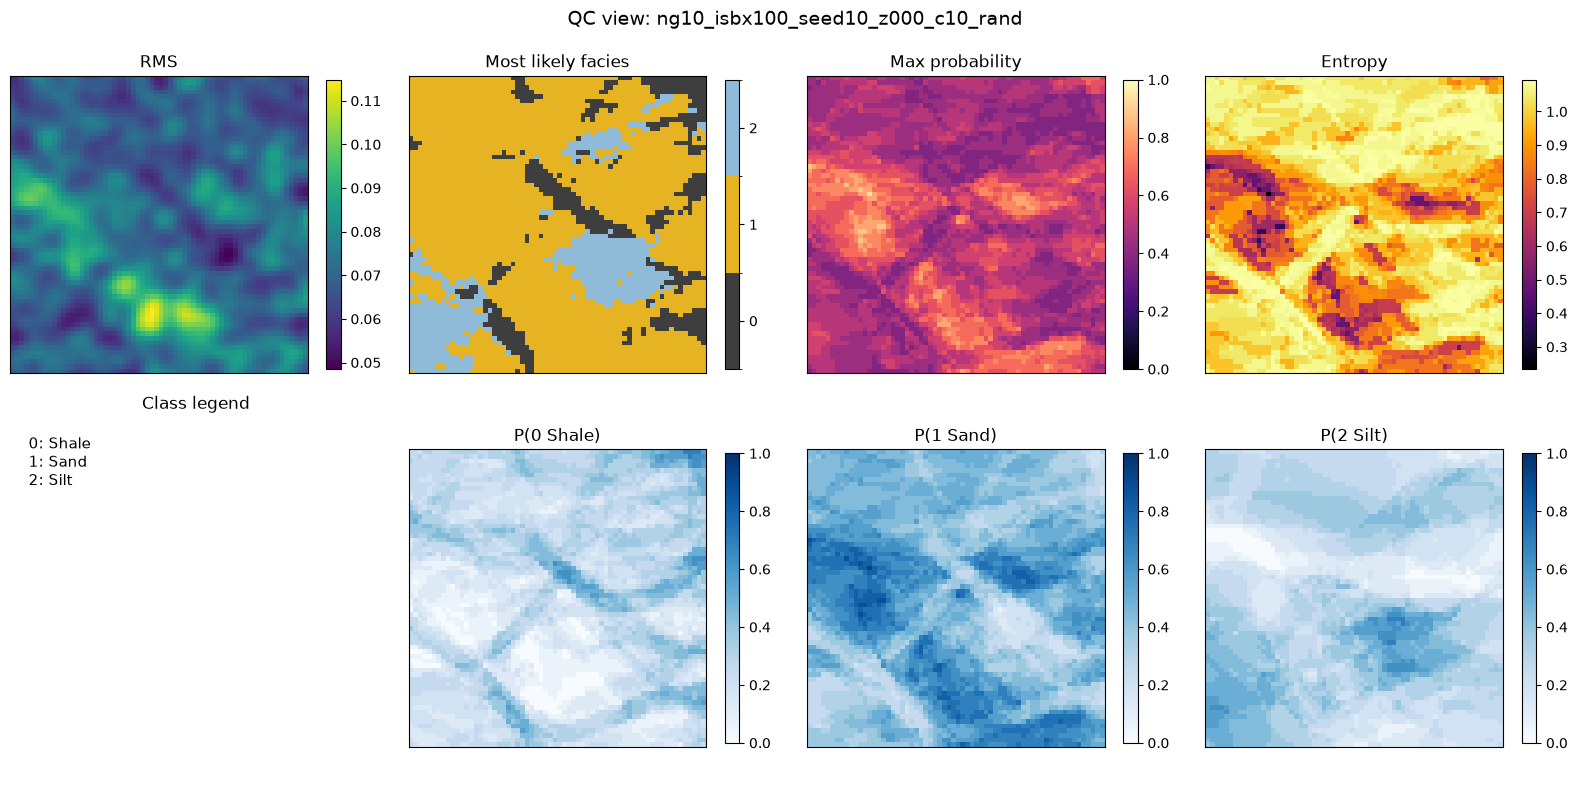

In [9]:
if len(results) == 0:
    raise RuntimeError('No inference results to visualize')

example_stem = df_summary.iloc[0]['file'] if len(df_summary) else list(results.keys())[0]
item = results[example_stem]

rms_map = item['rms']
pred = item['most_likely']
max_prob = item['max_prob']
entropy = item['entropy']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle(f'QC view: {example_stem}', fontsize=14)

im0 = axes[0, 0].imshow(rms_map, cmap='viridis', origin='lower')
axes[0, 0].set_title('RMS')
plt.colorbar(im0, ax=axes[0, 0], shrink=0.8)

im1 = axes[0, 1].imshow(pred, cmap=cmap6, norm=norm6, origin='lower')
axes[0, 1].set_title('Most likely facies')
plt.colorbar(im1, ax=axes[0, 1], ticks=np.arange(N_CLASSES), shrink=0.8)

im2 = axes[0, 2].imshow(max_prob, vmin=0.0, vmax=1.0, cmap='magma', origin='lower')
axes[0, 2].set_title('Max probability')
plt.colorbar(im2, ax=axes[0, 2], shrink=0.8)

im3 = axes[0, 3].imshow(entropy, cmap='inferno', origin='lower')
axes[0, 3].set_title('Entropy')
plt.colorbar(im3, ax=axes[0, 3], shrink=0.8)

legend_text = '\n'.join([f'{k}: {FACIES_NAMES[k]}' for k in range(N_CLASSES)])
axes[1, 0].text(0.05, 0.95, legend_text, va='top', fontsize=11)
axes[1, 0].set_title('Class legend')
axes[1, 0].axis('off')

for j, c in enumerate(range(N_CLASSES), start=1):
    imc = axes[1, j].imshow(item['probs'][c], vmin=0, vmax=1, cmap='Blues', origin='lower')
    axes[1, j].set_title(f'P({c} {FACIES_NAMES[c]})')
    plt.colorbar(imc, ax=axes[1, j], shrink=0.8)

for ax in axes.ravel():
    ax.set_xticks([])
    ax.set_yticks([])

plt.tight_layout()
plt.show()

## QC 3: Aggregate uncertainty diagnostics

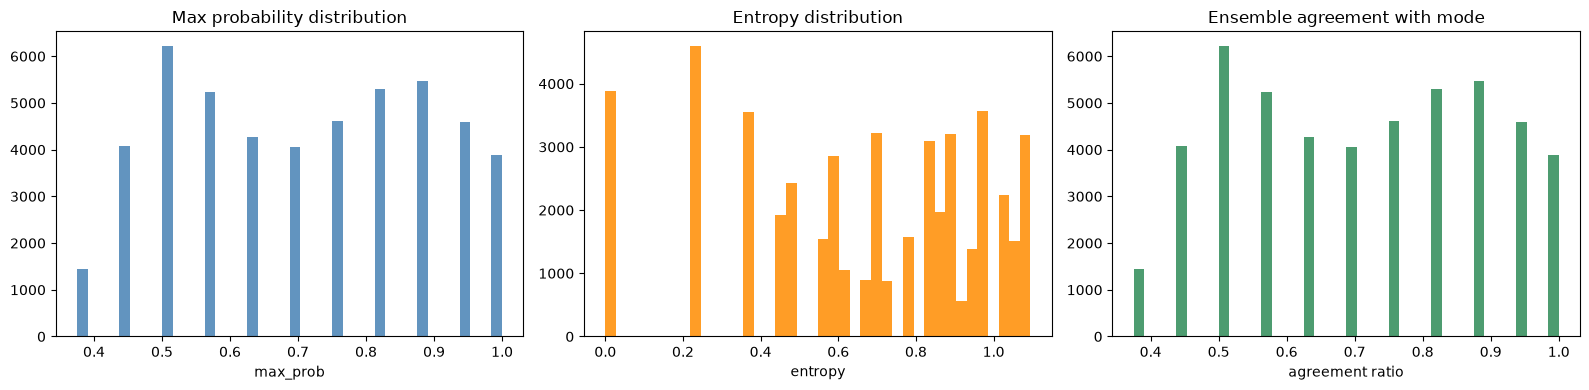

Global mean max_prob : 0.7033131718635559
Global mean entropy  : 0.6555357575416565
Global mean agreement: 0.7033131917317709


In [10]:
all_max_prob = np.concatenate([v['max_prob'].ravel() for v in results.values()])
all_entropy = np.concatenate([v['entropy'].ravel() for v in results.values()])

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(all_max_prob, bins=40, color='steelblue', alpha=0.85)
axes[0].set_title('Max probability distribution')
axes[0].set_xlabel('max_prob')

axes[1].hist(all_entropy, bins=40, color='darkorange', alpha=0.85)
axes[1].set_title('Entropy distribution')
axes[1].set_xlabel('entropy')

# Agreement across ensemble samples
agreements = []
for item in results.values():
    s = item['samples']  # (n_samples, H, W)
    mode = item['most_likely']
    agree = (s == mode[None, :, :]).mean(axis=0)
    agreements.append(agree.ravel())
agreements = np.concatenate(agreements)

axes[2].hist(agreements, bins=40, color='seagreen', alpha=0.85)
axes[2].set_title('Ensemble agreement with mode')
axes[2].set_xlabel('agreement ratio')

plt.tight_layout()
plt.show()

print('Global mean max_prob :', float(all_max_prob.mean()))
print('Global mean entropy  :', float(all_entropy.mean()))
print('Global mean agreement:', float(agreements.mean()))

## QC 4: Optional quantitative check against GT facies (if present)

Files with GT: 12


,file,pixel_acc,mIoU,mean_max_prob,mean_entropy
0,ng10_isbx100_seed10_z000_c10_rand,0.257568,0.108920,0.523621,0.956502
1,ng10_isbx100_seed10_z001_t6_tile,0.753418,0.381634,0.542969,0.943175
2,ng10_isbx100_seed10_z001_t9_tile,0.699707,0.421451,0.575012,0.866425
3,ng10_isbx100_seed10_z002_t12_tile,0.809570,0.428196,0.556839,0.863303
4,ng10_isbx100_seed10_z000_c8_rand,0.646973,0.311303,0.620697,0.771825
5,ng10_isbx100_seed10_z000_c0_rand,0.187012,0.101355,0.704788,0.728125
6,ng10_isbx100_seed10_z002_t4_tile,0.016602,0.008355,0.762451,0.574927
7,ng10_isbx100_seed10_z000_c9_rand,0.092041,0.032338,0.782654,0.561050
8,ng10_isbx100_seed10_z001_t7_tile,0.182617,0.075104,0.774246,0.528608
9,ng10_isbx100_seed10_z000_c7_rand,0.040039,0.020362,0.804916,0.511777


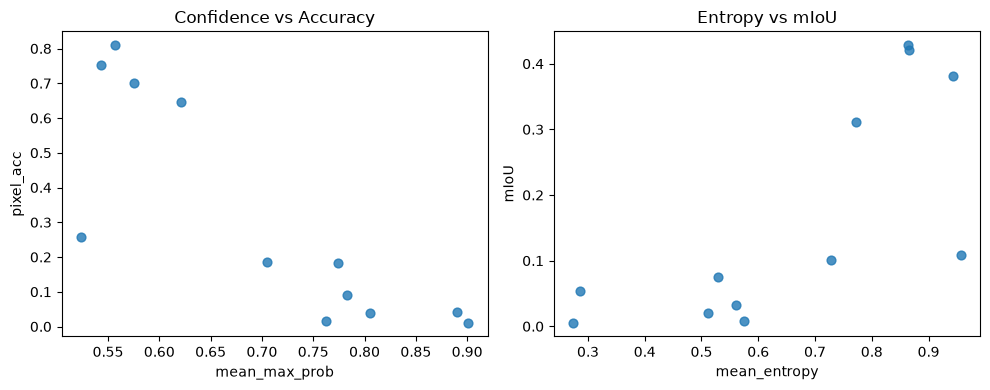

In [11]:
valid = df_summary.dropna(subset=['pixel_acc', 'mIoU']) if 'pixel_acc' in df_summary.columns else pd.DataFrame()
if len(valid) == 0:
    print('No matching GT facies files found (or shape mismatch). Skipping quantitative GT QC.')
else:
    print('Files with GT:', len(valid))
    display(valid[['file', 'pixel_acc', 'mIoU', 'mean_max_prob', 'mean_entropy']])

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].scatter(valid['mean_max_prob'], valid['pixel_acc'], s=40, alpha=0.8)
    axes[0].set_xlabel('mean_max_prob')
    axes[0].set_ylabel('pixel_acc')
    axes[0].set_title('Confidence vs Accuracy')

    axes[1].scatter(valid['mean_entropy'], valid['mIoU'], s=40, alpha=0.8)
    axes[1].set_xlabel('mean_entropy')
    axes[1].set_ylabel('mIoU')
    axes[1].set_title('Entropy vs mIoU')

    plt.tight_layout()
    plt.show()

## QC 5: Low/Mid/High NG × Low/Mid/High ISBX

This section selects representative `(ng, isbx)` combinations directly from available full-resolution cubes,
runs inference on a common depth slice for each case, and visualizes:
1. RMS input
2. Most-likely facies prediction
3. Ground-truth facies (reclassified + windowed mode)


Selected ng levels   : [np.int64(10), np.int64(50), np.int64(90)]
Selected isbx levels : [np.int64(20), np.int64(90), np.int64(160)]


,stem,ng,isbx,seed
0,ng10_isbx20_seed8,10,20,8
1,ng10_isbx90_seed8,10,90,8
2,ng10_isbx160_seed8,10,160,8
3,ng50_isbx20_seed8,50,20,8
4,ng50_isbx90_seed8,50,90,8
5,ng50_isbx160_seed8,50,160,8
6,ng90_isbx20_seed8,90,20,8
7,ng90_isbx90_seed8,90,90,8
8,ng90_isbx160_seed8,90,160,8


Multi-inference: 100%|██████████| 8/8 [00:14<00:00,  1.87s/it]


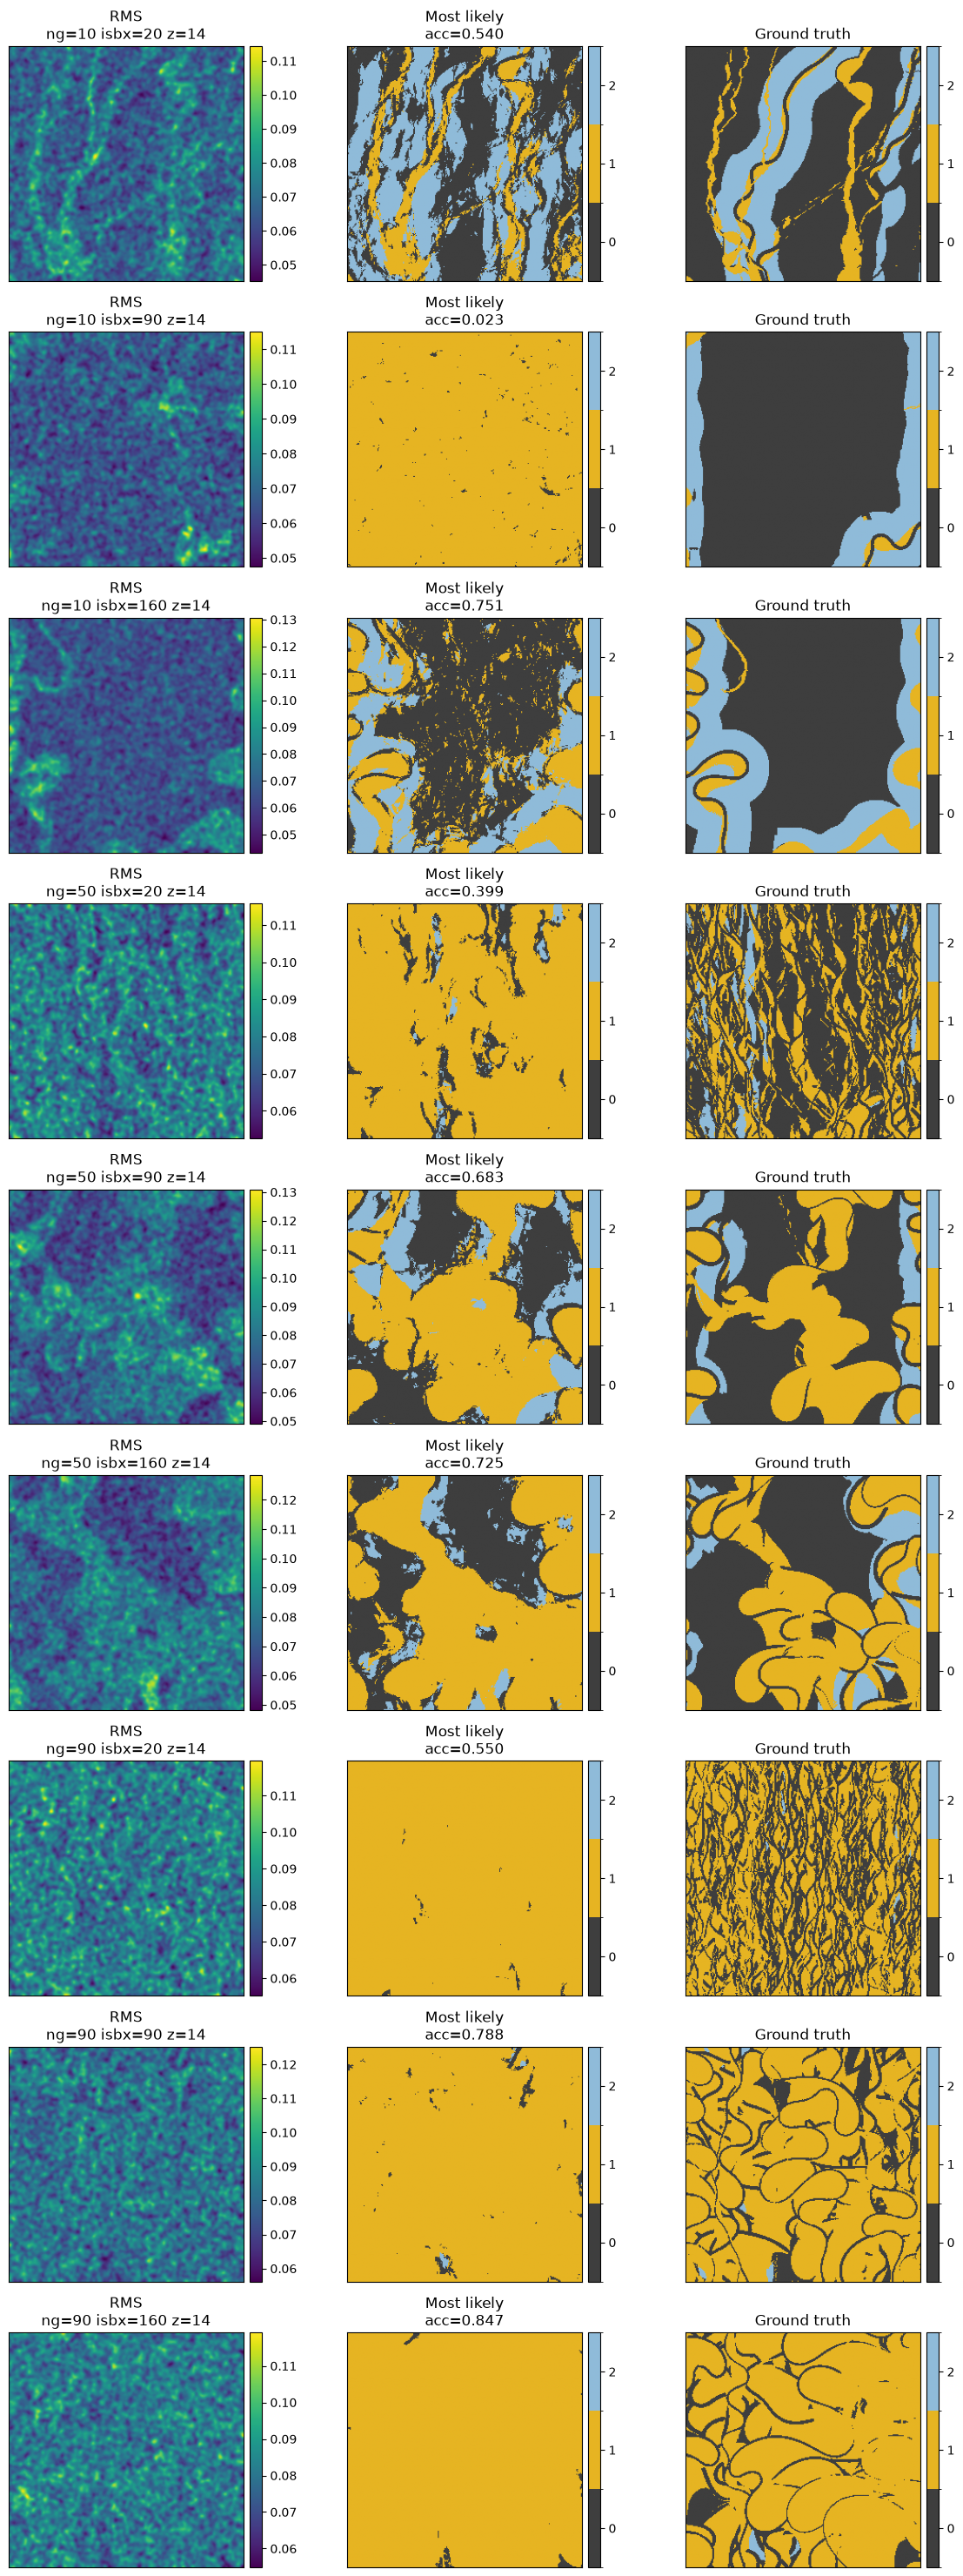

QC metrics for NG×ISBX grid:


,stem,ng,isbx,seed,z,pixel_acc,mean_max_prob,mean_entropy
0,ng10_isbx20_seed8,10,20,8,14,0.539856,0.632282,0.726963
1,ng10_isbx90_seed8,10,90,8,14,0.022949,0.867329,0.332126
2,ng10_isbx160_seed8,10,160,8,14,0.750717,0.568573,0.853577
3,ng50_isbx20_seed8,50,20,8,14,0.399231,0.848782,0.344636
4,ng50_isbx90_seed8,50,90,8,14,0.682739,0.748182,0.537289
5,ng50_isbx160_seed8,50,160,8,14,0.724991,0.784889,0.461616
6,ng90_isbx20_seed8,90,20,8,14,0.550385,0.956224,0.115575
7,ng90_isbx90_seed8,90,90,8,14,0.788315,0.911362,0.223451
8,ng90_isbx160_seed8,90,160,8,14,0.847275,0.963543,0.098984


In [18]:
import re
from diffsim.data.flumy_generator import FlumyGenerator, map_channelasso_to_litho
from diffsim.data.seismic import compute_facies_mode_window

FULL_RMS_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy3d/rms')
FULL_FACIES_DIR = Path('/mnt/sda_data/tharitt/diffsim/data/flumy3d/facies')
RMS_WINDOW_HALF = 2
GRID_N_SAMPLES = 8
GRID_DDIM_STEPS = 60
GRID_ETA = 0.3

pattern = re.compile(r'ng(?P<ng>\d+)_isbx(?P<isbx>\d+)_seed(?P<seed>\d+)')

catalog = []
for p in sorted(FULL_RMS_DIR.glob('*.npy')):
    m = pattern.fullmatch(p.stem)
    if not m:
        continue
    facies_path = FULL_FACIES_DIR / p.name
    if not facies_path.exists():
        continue
    catalog.append({
        'stem': p.stem,
        'rms_path': p,
        'facies_path': facies_path,
        'ng': int(m.group('ng')),
        'isbx': int(m.group('isbx')),
        'seed': int(m.group('seed')),
    })

if not catalog:
    raise RuntimeError(f'No matching cubes found under {FULL_RMS_DIR} and {FULL_FACIES_DIR}')

cat_df = pd.DataFrame(catalog).sort_values(['ng', 'isbx', 'seed']).reset_index(drop=True)

ng_values = sorted(cat_df['ng'].unique())
isbx_values = sorted(cat_df['isbx'].unique())

if len(ng_values) < 3 or len(isbx_values) < 3:
    raise RuntimeError(
        f'Need at least 3 unique ng and isbx values, got ng={ng_values}, isbx={isbx_values}'
    )

# Pick representative low/mid/high by sorted index
ng_levels = [ng_values[0], ng_values[len(ng_values)//2], ng_values[-1]]
isbx_levels = [isbx_values[0], isbx_values[len(isbx_values)//2], isbx_values[-1]]

print('Selected ng levels   :', ng_levels)
print('Selected isbx levels :', isbx_levels)

selected_cases = []
for ng in ng_levels:
    for isbx in isbx_levels:
        sub = cat_df[(cat_df['ng'] == ng) & (cat_df['isbx'] == isbx)]
        if len(sub) == 0:
            continue
        # choose median seed for stability
        case = sub.iloc[len(sub)//2].to_dict()
        selected_cases.append(case)

if len(selected_cases) == 0:
    raise RuntimeError('No (ng, isbx) combinations selected')

selected_df = pd.DataFrame(selected_cases).sort_values(['ng', 'isbx']).reset_index(drop=True)
display(selected_df[['stem', 'ng', 'isbx', 'seed']])

# Run inference and visualize RMS / prediction / GT
n_rows = len(selected_df)
fig, axes = plt.subplots(n_rows, 3, figsize=(12, 3.3 * n_rows), squeeze=False)

records = []
for i, row in selected_df.iterrows():
    rms_3d = np.load(row['rms_path'])
    facies_raw_3d = np.load(row['facies_path'])

    facies_6_3d = FlumyGenerator.reclassify_facies(facies_raw_3d)
    facies_mode_3d = compute_facies_mode_window(facies_6_3d, RMS_WINDOW_HALF)
    facies_mode_3d = map_channelasso_to_litho(facies_mode_3d)

    nz = min(rms_3d.shape[2], facies_mode_3d.shape[2])
    z = nz // 2

    rms_2d = rms_3d[:, :, z]
    gt_2d = facies_mode_3d[:, :, z]

    probs, samples, pred_2d = inference_full_resolution(
        network,
        rms_2d,
        n_samples=GRID_N_SAMPLES,
        ddim_steps=GRID_DDIM_STEPS,
        eta=GRID_ETA,
        device=DEVICE,
    )

    prob_stack = np.stack([probs[k] for k in range(N_CLASSES)], axis=-1)
    max_prob = prob_stack.max(axis=-1)
    entropy = -(prob_stack * np.log(prob_stack + 1e-8)).sum(axis=-1)

    pixel_acc = float((pred_2d == gt_2d).mean())
    records.append({
        'stem': row['stem'],
        'ng': row['ng'],
        'isbx': row['isbx'],
        'seed': row['seed'],
        'z': int(z),
        'pixel_acc': pixel_acc,
        'mean_max_prob': float(max_prob.mean()),
        'mean_entropy': float(entropy.mean()),
    })

    ax0, ax1, ax2 = axes[i]
    im0 = ax0.imshow(rms_2d, origin='lower', cmap='viridis')
    ax0.set_title(f"RMS\nng={row['ng']} isbx={row['isbx']} z={z}")
    plt.colorbar(im0, ax=ax0, fraction=0.046, pad=0.02)

    im1 = ax1.imshow(pred_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax1.set_title(f"Most likely\nacc={pixel_acc:.3f}")
    plt.colorbar(im1, ax=ax1, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    im2 = ax2.imshow(gt_2d, origin='lower', cmap=cmap6, norm=norm6)
    ax2.set_title("Ground truth")
    plt.colorbar(im2, ax=ax2, ticks=np.arange(N_CLASSES), fraction=0.046, pad=0.02)

    for a in (ax0, ax1, ax2):
        a.set_xticks([])
        a.set_yticks([])

plt.tight_layout()
plt.show()

qc_grid_df = pd.DataFrame(records).sort_values(['ng', 'isbx']).reset_index(drop=True)
print('QC metrics for NG×ISBX grid:')
display(qc_grid_df)
